<a href="https://colab.research.google.com/github/tillo37/python-projects/blob/main/Tabpfn_on_adults_salary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cols = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/adult.data",
    header=None,
    names=cols,
    skipinitialspace=True
)

print(df.head())

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [ ]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df["capital_loss"].nunique()

92

In [ ]:
X = df.drop("income", axis = 1)
y = df["income"]

In [ ]:
X

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [ ]:
y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
32556,<=50K
32557,>50K
32558,<=50K
32559,<=50K


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Encode target first (safe, binary)
le_target = LabelEncoder()
df['income'] = le_target.fit_transform(df['income'])  # <=50K=0, >50K=1

# Step 2: Separate X and y
X = df.drop('income', axis=1)
y = df['income']

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Encode categoricals (fit on train only)
categorical_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country'
]

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))  # transform only

# Step 5: Scale numerics (fit on train only)
numeric_cols = [
    'age', 'fnlwgt', 'education_num',
    'capital_gain', 'capital_loss', 'hours_per_week'
]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  # transform only

In [ ]:
X_train

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
15738,-0.483065,4,-1.448150,9,1.130540,2,4,0,4,1,-0.145319,-0.217362,0.363947,39
27985,0.323342,4,-0.834549,12,1.517666,4,4,1,4,0,-0.145319,-0.217362,0.363947,39
30673,-1.362782,0,-0.642204,11,-0.417965,4,0,1,4,0,-0.145319,-0.217362,-1.005102,39
9505,0.103413,2,-1.566121,15,-0.030839,0,14,4,4,1,0.793028,-0.217362,-0.038714,39
26417,-1.069543,4,-0.720946,9,1.130540,4,10,3,4,1,-0.145319,-0.217362,-0.038714,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8003,-0.263136,6,-0.102654,11,-0.417965,4,12,4,2,0,-0.145319,-0.217362,-0.199779,11
20560,0.030103,4,2.195383,15,-0.030839,0,11,4,2,0,-0.145319,-0.217362,-0.844037,39
23650,1.203059,4,-1.022705,11,-0.417965,2,4,0,1,1,-0.145319,-0.217362,1.169271,39
25301,-0.922924,4,-1.326425,9,1.130540,2,4,0,4,1,-0.145319,-0.217362,1.169271,39


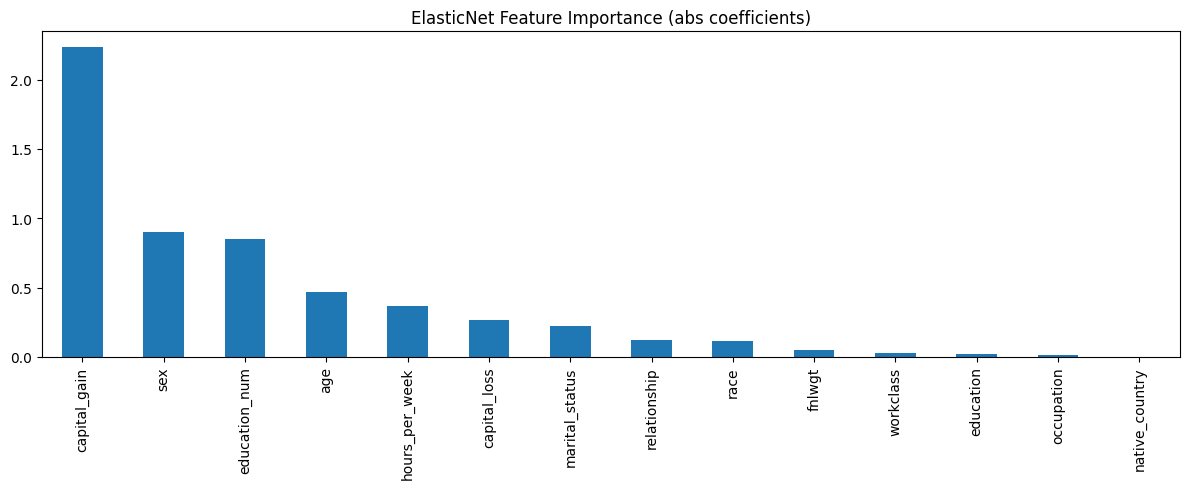

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# --- After your encoding and scaling pipeline ---

model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',          # required for elasticnet
    l1_ratio=1,           # 0=pure Ridge, 1=pure Lasso, 0.5=balanced
    C=1.0,
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

# --- Feature importance from coefficients ---
feature_names = df.drop('income', axis=1).columns
importance = pd.Series(np.abs(model.coef_[0]), index=feature_names)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title("ElasticNet Feature Importance (abs coefficients)")
plt.tight_layout()
plt.show()

In [ ]:
!pip install tabpfn shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.6/745.6 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import tabpfn
import shap
print("TabPFN version:", tabpfn.__version__)
print("SHAP version:", shap.__version__)


TabPFN version: 8.0.6
SHAP version: 0.51.0


In [ ]:
import os
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_xKSzLZakcQH829-_8m4YiME3n5boq1YWl4nDJDnNJhY"

In [ ]:

from tabpfn import TabPFNClassifier
import shap
import numpy as np

# --- Train TabPFN (no feature elimination) ---
model = TabPFNClassifier(device='cuda')
model.fit(X_train, y_train)

# --- Evaluate quickly ---
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4945
           1       0.76      0.65      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.86      6513



In [ ]:
# Use a background sample to speed up SHAP
background = shap.sample(X_train, 100)  # 100 background samples

explainer = shap.KernelExplainer(
    model.predict_proba,  # use predict_proba for classifiers
    background
)

# Explain a subset of test data (full set is very slow with KernelExplainer)
X_test_sample = X_test[:200]
shap_values = explainer.shap_values(X_test_sample)

# --- Plots ---
feature_names = df.drop('income', axis=1).columns.tolist()

# Summary bar plot (global importance)
shap.summary_plot(
    shap_values[1],  # index 1 = class ">50K"
    X_test_sample,
    feature_names=feature_names,
    plot_type="bar"
)

# Beeswarm plot (direction of impact)
shap.summary_plot(
    shap_values[1],
    X_test_sample,
    feature_names=feature_names
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
!nvidia-smi



/bin/bash: line 1: nvidia-smi: command not found
